In [1]:
"""Task 1: HOG feature extraction, recognition-rate evaluation and visualisation.

The 1-Nearest Neighbour model is used only as a fixed baseline evaluator.
The LBP experiment must use the same data split and evaluator settings so
that the two feature extraction techniques can be compared fairly.
"""

import argparse
import csv
import hashlib
import sys
from pathlib import Path

import cv2
import numpy as np
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer


# ---------------------------------------------------------
# Settings
# ---------------------------------------------------------

TRAIN_DIR = Path(
    r"C:\Users\ACER\Downloads\UCCC2513 MINI PROJECT\Other\asg2\archive"
)

ANNOTATION_FILE = TRAIN_DIR / "annotations.csv"

IMAGE_DIR = TRAIN_DIR / "images"

TEST_DIR = Path(
    r"C:\Users\ACER\Downloads\UCCC2513 MINI PROJECT\Other\asg2\Inputs"
)

IMAGE_SIZE = (64, 64)
DISPLAY_COUNT = 10
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".ppm", ".bmp"}
VALIDATION_SIZE = 0.20
RANDOM_SEED = 42


# ---------------------------------------------------------
# Read and clean annotations
# ---------------------------------------------------------

def read_annotations():
    labels_by_filename = {}

    with ANNOTATION_FILE.open(
        newline="",
        encoding="utf-8-sig"
    ) as file:

        reader = csv.DictReader(file)

        for row in reader:
            filename = row["file_name"].strip()
            category = int(float(row["category"]))
            image_path = IMAGE_DIR / filename

            if not image_path.exists():
                continue

            # Keep only one annotation for each filename
            labels_by_filename.setdefault(filename, category)

    return labels_by_filename


def image_hash(path):
    """Return a SHA-256 hash used to detect exact train-test duplicates."""
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def make_colour_mask(image):
    """Create a mask for common red, blue and yellow traffic-sign colours."""
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    red = cv2.bitwise_or(
        cv2.inRange(hsv, (0, 70, 40), (10, 255, 255)),
        cv2.inRange(hsv, (170, 70, 40), (180, 255, 255))
    )
    blue = cv2.inRange(hsv, (90, 60, 35), (140, 255, 255))
    yellow = cv2.inRange(hsv, (15, 70, 45), (40, 255, 255))
    mask = cv2.bitwise_or(cv2.bitwise_or(red, blue), yellow)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    return cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)


def extract_sign_region(image):
    """Automatically locate and crop the most likely traffic-sign region."""
    mask = make_colour_mask(image)
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
    candidates = []

    for contour in contours:
        area = cv2.contourArea(contour)
        x, y, width, height = cv2.boundingRect(contour)
        aspect_ratio = width / max(height, 1)
        if area >= 80 and 0.45 <= aspect_ratio <= 1.8:
            candidates.append((area, x, y, width, height))

    if not candidates:
        return image

    _, x, y, width, height = max(candidates)
    padding = max(3, int(0.10 * max(width, height)))
    x1, y1 = max(0, x - padding), max(0, y - padding)
    x2 = min(image.shape[1], x + width + padding)
    y2 = min(image.shape[0], y + height + padding)
    cropped_sign = image[y1:y2, x1:x2]
    return cropped_sign if cropped_sign.size else image


# ---------------------------------------------------------
# Task 1: HOG feature extraction
# ---------------------------------------------------------

def extract_hog(image, create_visualisation=False):
    if image is None or image.size == 0:
        raise ValueError("The supplied image is empty.")

    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Standardise image size
    gray = cv2.resize(
        gray,
        IMAGE_SIZE,
        interpolation=cv2.INTER_AREA
    )

    result = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=create_visualisation,
        feature_vector=True
    )

    if create_visualisation:
        features, hog_image = result

        hog_image = cv2.normalize(
            hog_image,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        ).astype(np.uint8)

        return features.astype(np.float32), gray, hog_image

    return result.astype(np.float32)


# ---------------------------------------------------------
# Prepare popup visualisation
# ---------------------------------------------------------

def add_title(image, title):
    panel = cv2.resize(image, (300, 300))

    title_area = np.zeros(
        (45, panel.shape[1], 3),
        dtype=np.uint8
    )

    cv2.putText(
        title_area,
        title,
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.75,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )

    return cv2.vconcat([title_area, panel])


def create_display(
    image,
    cropped_sign,
    gray,
    hog_image,
    filename,
    expected,
    predicted
):
    original_panel = add_title(
        image,
        "Original"
    )

    cropped_panel = add_title(
        cropped_sign,
        "Cropped Sign"
    )

    grayscale_panel = add_title(
        cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR),
        "Grayscale"
    )

    hog_panel = add_title(
        cv2.cvtColor(hog_image, cv2.COLOR_GRAY2BGR),
        "HOG Features"
    )

    panels = cv2.hconcat([
        original_panel,
        cropped_panel,
        grayscale_panel,
        hog_panel
    ])

    header = np.zeros(
        (70, panels.shape[1], 3),
        dtype=np.uint8
    )

    cv2.putText(
        header,
        (
            f"File: {filename} | Expected: {expected:03d} | "
            f"Predicted: {predicted:03d}"
        ),
        (15, 28),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.70,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )

    correct = expected == predicted
    cv2.putText(
        header,
        "CORRECT" if correct else "WRONG",
        (panels.shape[1] - 145, 28),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.70,
        (0, 220, 0) if correct else (0, 0, 255),
        2,
        cv2.LINE_AA
    )

    cv2.putText(
        header,
        "Any key = next image | Esc = stop",
        (15, 55),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (180, 220, 255),
        1,
        cv2.LINE_AA
    )

    return cv2.vconcat([header, panels])


def terminal_status(correct):
    """Return green/red status text when the terminal supports ANSI colour."""
    text = "CORRECT" if correct else "WRONG"
    if not sys.stdout.isatty():
        return text
    colour = "\033[92m" if correct else "\033[91m"
    return f"{colour}{text}\033[0m"


# ---------------------------------------------------------
# Run Task 1 HOG recognition-rate experiment
# ---------------------------------------------------------

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--no-popup",
        action="store_true",
        help="Print results without opening the visualisation window."
    )
    options = parser.parse_args(args=[])

    if not ANNOTATION_FILE.exists():
        raise FileNotFoundError(
            f"annotations.csv was not found: {ANNOTATION_FILE}"
        )

    labels_by_filename = read_annotations()
    test_paths = sorted(
        path for path in TEST_DIR.rglob("*")
        if path.suffix.lower() in IMAGE_EXTENSIONS
    )

    if not test_paths:
        raise FileNotFoundError(f"No testing images were found: {TEST_DIR}")

    # The lecturer test set must remain independent from model fitting.
    test_hashes = {image_hash(path) for path in test_paths}
    training_images = sorted([
        (IMAGE_DIR / filename, category)
        for filename, category in labels_by_filename.items()
        if image_hash(IMAGE_DIR / filename) not in test_hashes
    ], key=lambda item: item[0].name.lower())
    removed_count = len(labels_by_filename) - len(training_images)

    feature_list = []
    label_list = []

    print("=" * 68)
    print("TASK 1: HOG FEATURE EXTRACTION AND RECOGNITION RATE")
    print("=" * 68)
    print(f"Unique training images           : {len(labels_by_filename)}")
    print(f"Exact test-image matches removed : {removed_count}")
    print(f"Clean training images            : {len(training_images)}")
    print(f"Lecturer testing images          : {len(test_paths)}")
    print("Extracting HOG features...")

    for image_path, category in training_images:
        image = cv2.imread(str(image_path))

        if image is None:
            print(f"Skipped unreadable image: {image_path.name}")
            continue

        # Use the same automatic region extraction for training and testing.
        cropped_sign = extract_sign_region(image)
        features = extract_hog(cropped_sign)

        feature_list.append(features)
        label_list.append(category)

    if not feature_list:
        raise RuntimeError("No valid training images could be processed.")

    # Complete HOG feature matrix before the stratified 80/20 split.
    X_all = np.vstack(feature_list)
    y_all = np.asarray(label_list)

    print("\nHOG extraction completed.")
    print(f"Images successfully processed   : {len(X_all)}")
    print(f"HOG features per image          : {X_all.shape[1]}")
    print(f"HOG feature matrix shape        : {X_all.shape}")
    print(f"Label array shape               : {y_all.shape}")

    X_train, X_validation, y_train, y_validation = train_test_split(
        X_all,
        y_all,
        test_size=VALIDATION_SIZE,
        random_state=RANDOM_SEED,
        stratify=y_all
    )

    print("\nFixed evaluation protocol")
    print("Evaluator                        : 1-Nearest Neighbour")
    print("Distance                         : Euclidean")
    print("Feature normalisation            : L2")
    print(f"Training samples                 : {len(X_train)}")
    print(f"Validation samples               : {len(X_validation)}")

    evaluator = make_pipeline(
        Normalizer(norm="l2"),
        KNeighborsClassifier(
            n_neighbors=1,
            metric="euclidean",
            n_jobs=-1
        )
    )

    # Validation recognition rate: fit only on the 80% training partition.
    evaluator.fit(X_train, y_train)
    validation_predictions = evaluator.predict(X_validation)
    validation_correct = int(np.sum(validation_predictions == y_validation))
    validation_total = len(y_validation)
    validation_rate = validation_correct / validation_total

    # Apply exactly the same HOG preprocessing to the lecturer test images.
    test_features = []
    test_labels = []
    valid_test_paths = []

    for image_path in test_paths:
        image = cv2.imread(str(image_path))
        if image is None:
            print(f"Skipped unreadable testing image: {image_path.name}")
            continue

        cropped_sign = extract_sign_region(image)
        test_features.append(extract_hog(cropped_sign))
        test_labels.append(int(image_path.name.split("_")[0]))
        valid_test_paths.append(image_path)

    if not test_features:
        raise RuntimeError("No valid lecturer testing images could be processed.")

    X_test = np.vstack(test_features)
    y_test = np.asarray(test_labels)

    # Save HOG features for Task 2
    np.save("hog_X_all.npy", X_all)
    np.save("hog_y_all.npy", y_all)
    np.save("hog_X_test.npy", X_test)
    np.save("hog_y_test.npy", y_test)
    
    print("\nHOG features saved for Task 2.")

    # After validation, refit the same evaluator on all clean training data.
    evaluator.fit(X_all, y_all)
    test_predictions = evaluator.predict(X_test)
    test_correct = int(np.sum(test_predictions == y_test))
    test_total = len(y_test)
    test_rate = test_correct / test_total

    print("\n" + "=" * 68)
    print("LECTURER TEST PREDICTIONS")
    print("=" * 68)
    for number, (path, expected, predicted) in enumerate(
        zip(valid_test_paths, y_test, test_predictions),
        start=1
    ):
        correct = expected == predicted
        print(
            f"{number:>3}. {path.name:<22} "
            f"expected={expected:03d} predicted={predicted:03d} "
            f"{terminal_status(correct)}"
        )

    print("\n" + "=" * 68)
    print("HOG RECOGNITION-RATE RESULTS")
    print("=" * 68)
    print(
        f"Validation recognition rate     : {validation_correct}/"
        f"{validation_total} = {validation_rate * 100:.2f}%"
    )
    print(
        f"Lecturer test recognition rate  : {test_correct}/"
        f"{test_total} = {test_rate * 100:.2f}%"
    )
    print("Fixed evaluator                  : 1-Nearest Neighbour")
    print(f"Visualisation results            : {min(DISPLAY_COUNT, test_total)}")

    if options.no_popup:
        return

    print("\nPress any key for the next image.")
    print("Press Esc to stop.")

    cv2.namedWindow(
        "Task 1 - HOG Feature Extraction",
        cv2.WINDOW_NORMAL
    )

    indices = np.linspace(
        0,
        test_total - 1,
        num=min(DISPLAY_COUNT, test_total),
        dtype=int
    )

    for index in indices:
        image_path = valid_test_paths[index]
        image = cv2.imread(str(image_path))
        cropped_sign = extract_sign_region(image)
        _, gray, hog_image = extract_hog(
            cropped_sign,
            create_visualisation=True
        )
        display = create_display(
            image,
            cropped_sign,
            gray,
            hog_image,
            image_path.name,
            int(y_test[index]),
            int(test_predictions[index])
        )

        cv2.imshow(
            "Task 1 - HOG Feature Extraction",
            display
        )

        key = cv2.waitKey(0) & 0xFF

        if key == 27:
            break

    cv2.destroyAllWindows()


if __name__ == "__main__":
    main()


TASK 1: HOG FEATURE EXTRACTION AND RECOGNITION RATE
Unique training images           : 5998
Exact test-image matches removed : 250
Clean training images            : 5748
Lecturer testing images          : 84
Extracting HOG features...

HOG extraction completed.
Images successfully processed   : 5748
HOG features per image          : 1764
HOG feature matrix shape        : (5748, 1764)
Label array shape               : (5748,)

Fixed evaluation protocol
Evaluator                        : 1-Nearest Neighbour
Distance                         : Euclidean
Feature normalisation            : L2
Training samples                 : 4598
Validation samples               : 1150

HOG features saved for Task 2.

LECTURER TEST PREDICTIONS
  1. 020_0002_j.png         expected=020 predicted=020 CORRECT
  2. 020_0003.png           expected=020 predicted=020 CORRECT
  3. 020_0004.png           expected=020 predicted=020 CORRECT
  4. 020_0006.png           expected=020 predicted=020 CORRECT
  5. 021_0002_

TASK 2: HOG + SVM CLASSIFICATION

Loading HOG features saved from Task 1...
HOG features loaded successfully.
Training feature matrix : (5748, 1764)
Training labels         : (5748,)
Test feature matrix    : (84, 1764)
Test labels             : (84,)

TRAIN / VALIDATION SPLIT
Training samples   : 4598
Validation samples : 1150

Scaling HOG features...
Feature scaling completed.

SELECTED SVM PARAMETERS
Kernel : RBF
C      : 10
Gamma  : scale

SVM TRAINING
Training SVM...
SVM training completed.

Making training predictions...
Training prediction completed.

Making validation predictions...
Validation prediction completed.

TRAINING AND VALIDATION RESULTS

TRAINING SET
----------------------------------------------------------------------
Accuracy  : 1.0000 (100.00%)
Precision : 1.0000 (100.00%)
Recall    : 1.0000 (100.00%)
F1-score  : 1.0000 (100.00%)

VALIDATION SET
----------------------------------------------------------------------
Accuracy  : 0.9930 (99.30%)
Precision : 0.9933 (9

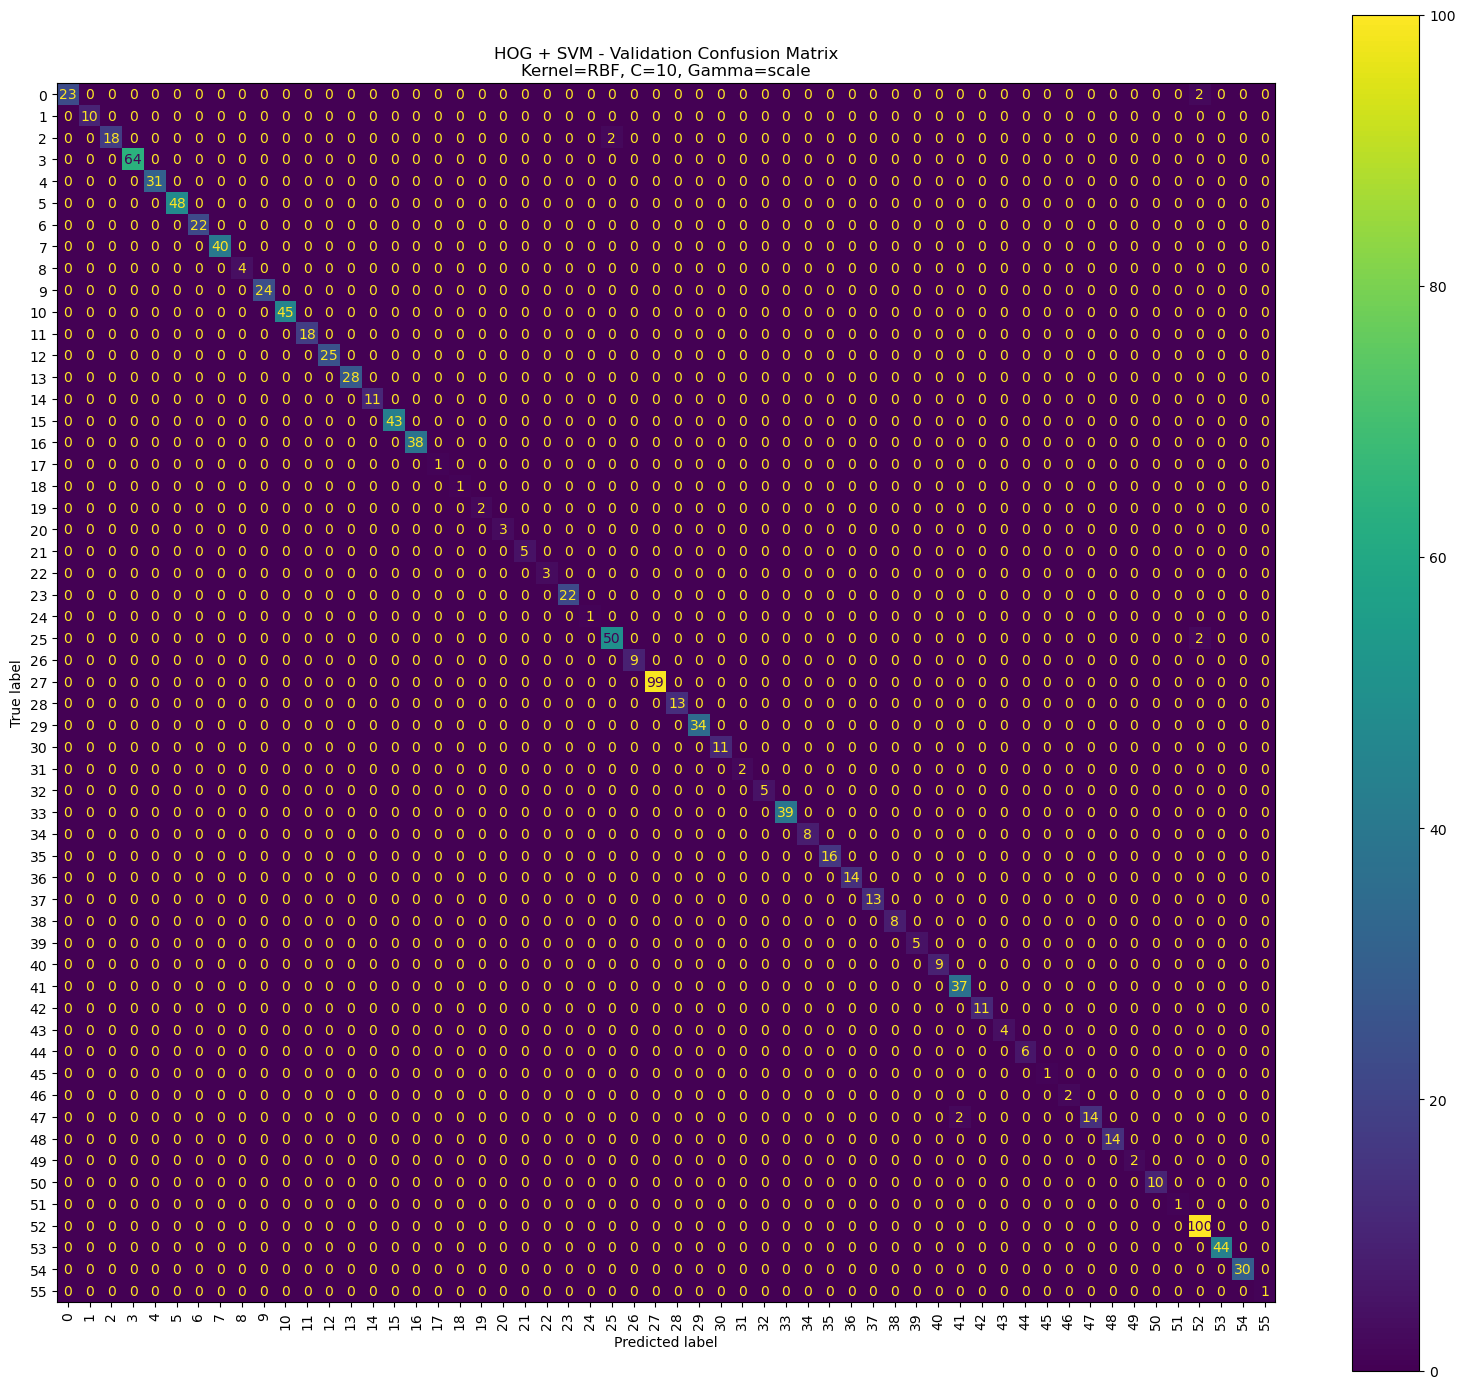


FINAL SVM TRAINING
Scaling all HOG training features...
Scaling completed.

Training final SVM using all HOG training features...
Final SVM training completed!

Making final training predictions...
Final training prediction completed.

Making final test predictions...
Test prediction completed.

FINAL PERFORMANCE COMPARISON
Dataset        Accuracy       Precision      Recall         F1-score       
----------------------------------------------------------------------
Training       100.00         100.00         100.00         100.00         
Validation     99.30          99.33          99.30          99.30          
Test           80.95          82.67          80.95          79.76          

FINAL TEST RESULTS - HOG + SVM
Kernel     : RBF
C          : 10
Gamma      : scale
Test images: 84

Accuracy   : 0.8095 (80.95%)
Precision  : 0.8267 (82.67%)
Recall     : 0.8095 (80.95%)
F1-score   : 0.7976 (79.76%)

FINAL TEST CLASSIFICATION REPORT
              precision    recall  f1-score   s

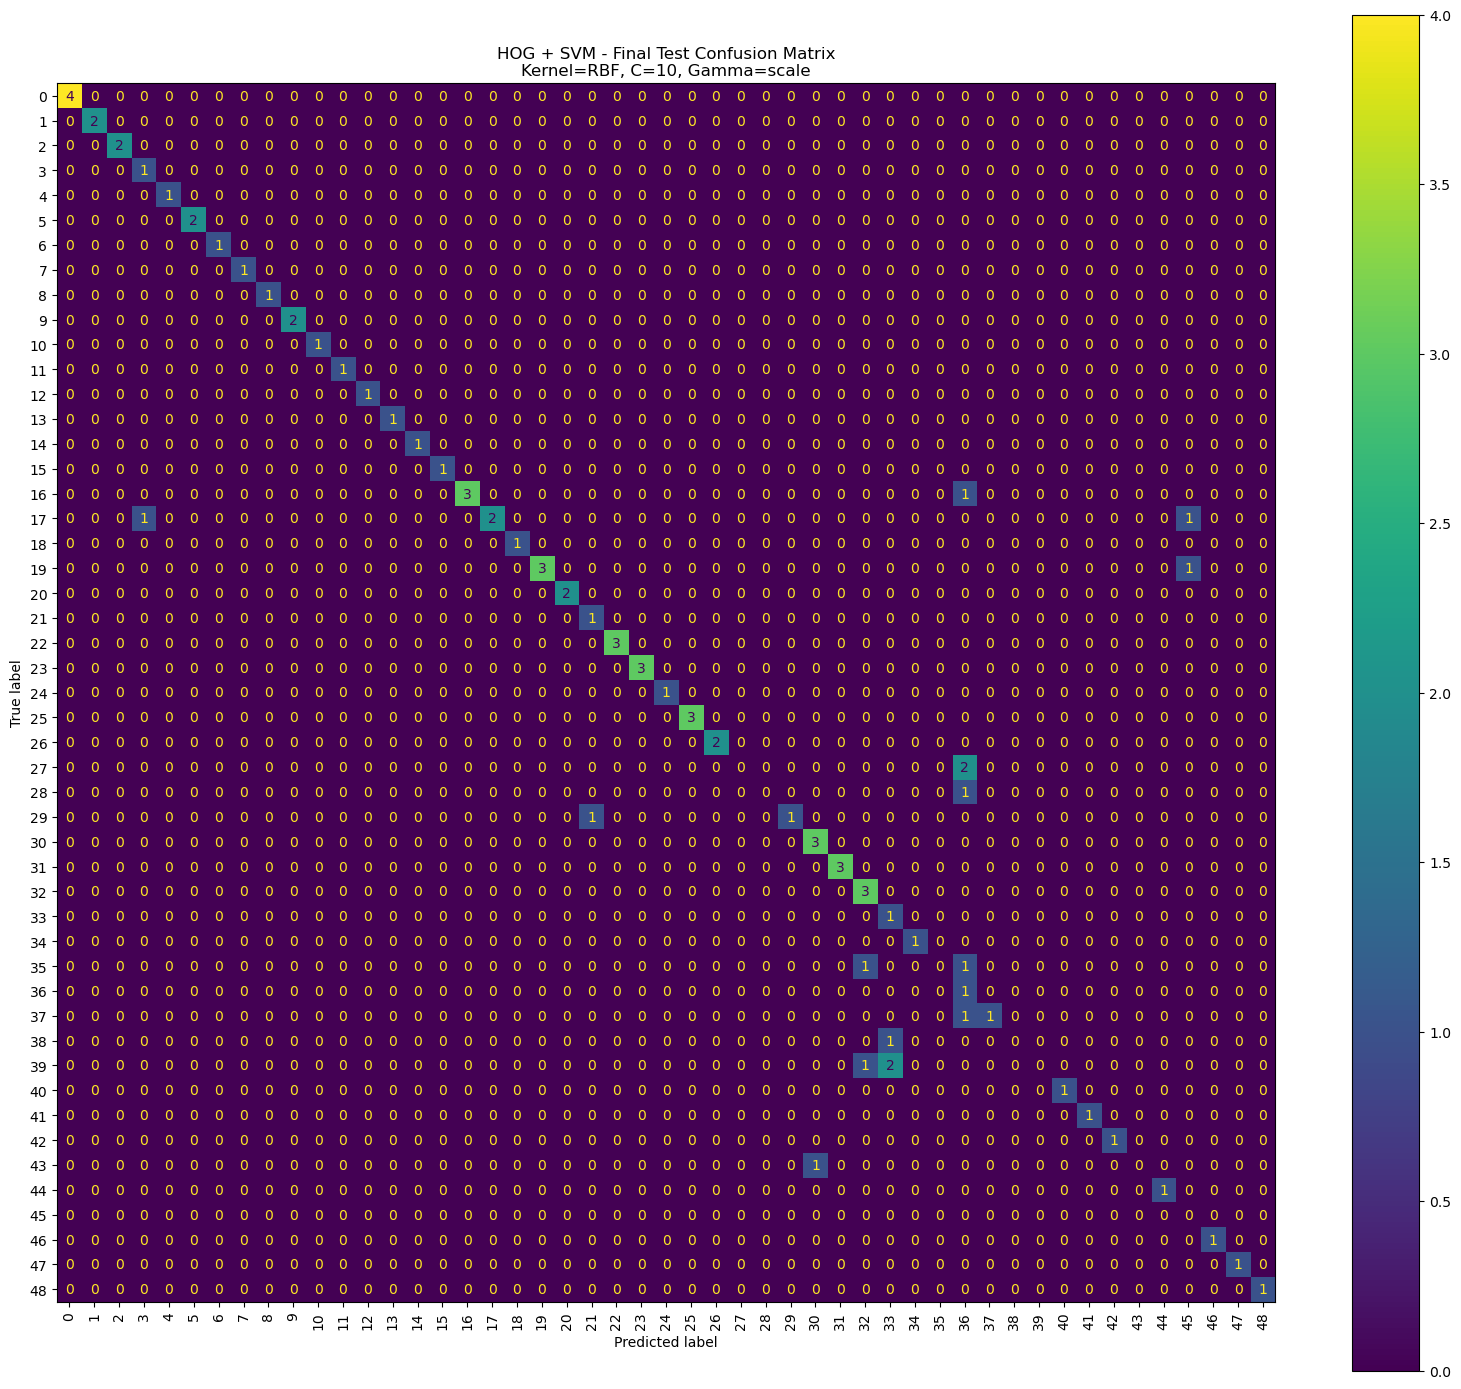


HOG + SVM FINAL SUMMARY
Best Kernel : RBF
Best C      : 10
Best Gamma  : scale

Training Performance
Accuracy  : 100.00%
Precision : 100.00%
Recall    : 100.00%
F1-score  : 100.00%

Validation Performance
Accuracy  : 99.30%
Precision : 99.33%
Recall    : 99.30%
F1-score  : 99.30%

Test Performance
Accuracy  : 80.95%
Precision : 82.67%
Recall    : 80.95%
F1-score  : 79.76%


In [4]:
# ============================================================
# TASK 2: HOG + SVM CLASSIFICATION
# SELECTED PARAMETERS: RBF, C=10, GAMMA=scale
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# PART 1: LOAD SAVED HOG FEATURES
# ============================================================

print("=" * 70)
print("TASK 2: HOG + SVM CLASSIFICATION")
print("=" * 70)

print("\nLoading HOG features saved from Task 1...")

X_all = np.load("hog_X_all.npy")
y_all = np.load("hog_y_all.npy")

X_test = np.load("hog_X_test.npy")
y_test = np.load("hog_y_test.npy")

print("HOG features loaded successfully.")
print(f"Training feature matrix : {X_all.shape}")
print(f"Training labels         : {y_all.shape}")
print(f"Test feature matrix    : {X_test.shape}")
print(f"Test labels             : {y_test.shape}")


# ============================================================
# PART 2: TRAIN / VALIDATION SPLIT
# ============================================================

print("\n" + "=" * 70)
print("TRAIN / VALIDATION SPLIT")
print("=" * 70)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    random_state=42,
    stratify=y_all
)

print(f"Training samples   : {len(X_train)}")
print(f"Validation samples : {len(X_validation)}")


# ============================================================
# PART 3: FEATURE SCALING
# ============================================================

print("\nScaling HOG features...")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)

print("Feature scaling completed.")


# ============================================================
# PART 4: SELECT SVM PARAMETERS
# ============================================================

print("\n" + "=" * 70)
print("SELECTED SVM PARAMETERS")
print("=" * 70)

kernel = "rbf"
C = 10
gamma = "scale"

print(f"Kernel : {kernel.upper()}")
print(f"C      : {C}")
print(f"Gamma  : {gamma}")


# ============================================================
# PART 5: TRAIN SVM
# ============================================================

print("\n" + "=" * 70)
print("SVM TRAINING")
print("=" * 70)

svm_model = SVC(
    kernel=kernel,
    C=C,
    gamma=gamma
)

print("Training SVM...")

svm_model.fit(
    X_train_scaled,
    y_train
)

print("SVM training completed.")


# ============================================================
# PART 6: TRAINING PREDICTION
# ============================================================

print("\nMaking training predictions...")

y_train_pred = svm_model.predict(
    X_train_scaled
)

print("Training prediction completed.")


# ============================================================
# PART 7: VALIDATION PREDICTION
# ============================================================

print("\nMaking validation predictions...")

y_validation_pred = svm_model.predict(
    X_validation_scaled
)

print("Validation prediction completed.")


# ============================================================
# PART 8: TRAINING RESULTS
# ============================================================

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

train_precision = precision_score(
    y_train,
    y_train_pred,
    average="weighted",
    zero_division=0
)

train_recall = recall_score(
    y_train,
    y_train_pred,
    average="weighted",
    zero_division=0
)

train_f1 = f1_score(
    y_train,
    y_train_pred,
    average="weighted",
    zero_division=0
)


# ============================================================
# PART 9: VALIDATION RESULTS
# ============================================================

validation_accuracy = accuracy_score(
    y_validation,
    y_validation_pred
)

validation_precision = precision_score(
    y_validation,
    y_validation_pred,
    average="weighted",
    zero_division=0
)

validation_recall = recall_score(
    y_validation,
    y_validation_pred,
    average="weighted",
    zero_division=0
)

validation_f1 = f1_score(
    y_validation,
    y_validation_pred,
    average="weighted",
    zero_division=0
)


# ============================================================
# PART 10: DISPLAY TRAINING AND VALIDATION RESULTS
# ============================================================

print("\n" + "=" * 70)
print("TRAINING AND VALIDATION RESULTS")
print("=" * 70)

print("\nTRAINING SET")
print("-" * 70)

print(f"Accuracy  : {train_accuracy:.4f} "
      f"({train_accuracy * 100:.2f}%)")

print(f"Precision : {train_precision:.4f} "
      f"({train_precision * 100:.2f}%)")

print(f"Recall    : {train_recall:.4f} "
      f"({train_recall * 100:.2f}%)")

print(f"F1-score  : {train_f1:.4f} "
      f"({train_f1 * 100:.2f}%)")


print("\nVALIDATION SET")
print("-" * 70)

print(f"Accuracy  : {validation_accuracy:.4f} "
      f"({validation_accuracy * 100:.2f}%)")

print(f"Precision : {validation_precision:.4f} "
      f"({validation_precision * 100:.2f}%)")

print(f"Recall    : {validation_recall:.4f} "
      f"({validation_recall * 100:.2f}%)")

print(f"F1-score  : {validation_f1:.4f} "
      f"({validation_f1 * 100:.2f}%)")


# ============================================================
# PART 11: VALIDATION CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("VALIDATION CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_validation,
        y_validation_pred,
        zero_division=0
    )
)


# ============================================================
# PART 12: VALIDATION CONFUSION MATRIX
# ============================================================

print("\nGenerating validation confusion matrix...")

cm_validation = confusion_matrix(
    y_validation,
    y_validation_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_validation
)

fig, ax = plt.subplots(figsize=(16, 14))

disp.plot(
    ax=ax,
    xticks_rotation="vertical"
)

ax.set_title(
    f"HOG + SVM - Validation Confusion Matrix\n"
    f"Kernel=RBF, C={C}, Gamma={gamma}"
)

plt.tight_layout()
plt.show()


# ============================================================
# PART 13: SCALE ALL TRAINING FEATURES
# ============================================================

print("\n" + "=" * 70)
print("FINAL SVM TRAINING")
print("=" * 70)

print("Scaling all HOG training features...")

final_scaler = StandardScaler()

X_all_scaled = final_scaler.fit_transform(
    X_all
)

X_test_scaled = final_scaler.transform(
    X_test
)

print("Scaling completed.")


# ============================================================
# PART 14: TRAIN FINAL SVM USING ALL TRAINING DATA
# ============================================================

print("\nTraining final SVM using all HOG training features...")

final_svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

final_svm.fit(
    X_all_scaled,
    y_all
)

print("Final SVM training completed!")


# ============================================================
# PART 15: FINAL TRAINING PREDICTION
# ============================================================

print("\nMaking final training predictions...")

y_all_pred = final_svm.predict(
    X_all_scaled
)

print("Final training prediction completed.")


# ============================================================
# PART 16: FINAL TEST PREDICTION
# ============================================================

print("\nMaking final test predictions...")

y_test_pred = final_svm.predict(
    X_test_scaled
)

print("Test prediction completed.")


# ============================================================
# PART 17: FINAL TRAINING RESULTS
# ============================================================

final_train_accuracy = accuracy_score(
    y_all,
    y_all_pred
)

final_train_precision = precision_score(
    y_all,
    y_all_pred,
    average="weighted",
    zero_division=0
)

final_train_recall = recall_score(
    y_all,
    y_all_pred,
    average="weighted",
    zero_division=0
)

final_train_f1 = f1_score(
    y_all,
    y_all_pred,
    average="weighted",
    zero_division=0
)


# ============================================================
# PART 18: FINAL TEST RESULTS
# ============================================================

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)


# ============================================================
# PART 19: FINAL COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("FINAL PERFORMANCE COMPARISON")
print("=" * 70)

print(f"{'Dataset':<15}"
      f"{'Accuracy':<15}"
      f"{'Precision':<15}"
      f"{'Recall':<15}"
      f"{'F1-score':<15}")

print("-" * 70)

print(f"{'Training':<15}"
      f"{final_train_accuracy * 100:<15.2f}"
      f"{final_train_precision * 100:<15.2f}"
      f"{final_train_recall * 100:<15.2f}"
      f"{final_train_f1 * 100:<15.2f}")

print(f"{'Validation':<15}"
      f"{validation_accuracy * 100:<15.2f}"
      f"{validation_precision * 100:<15.2f}"
      f"{validation_recall * 100:<15.2f}"
      f"{validation_f1 * 100:<15.2f}")

print(f"{'Test':<15}"
      f"{test_accuracy * 100:<15.2f}"
      f"{test_precision * 100:<15.2f}"
      f"{test_recall * 100:<15.2f}"
      f"{test_f1 * 100:<15.2f}")


# ============================================================
# PART 20: FINAL TEST RESULTS
# ============================================================

print("\n" + "=" * 70)
print("FINAL TEST RESULTS - HOG + SVM")
print("=" * 70)

print("Kernel     : RBF")
print("C          : 10")
print("Gamma      : scale")
print(f"Test images: {len(y_test)}")

print()
print(f"Accuracy   : {test_accuracy:.4f} "
      f"({test_accuracy * 100:.2f}%)")

print(f"Precision  : {test_precision:.4f} "
      f"({test_precision * 100:.2f}%)")

print(f"Recall     : {test_recall:.4f} "
      f"({test_recall * 100:.2f}%)")

print(f"F1-score   : {test_f1:.4f} "
      f"({test_f1 * 100:.2f}%)")


# ============================================================
# PART 21: FINAL CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("FINAL TEST CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_test_pred,
        zero_division=0
    )
)


# ============================================================
# PART 22: FINAL CONFUSION MATRIX
# ============================================================

print("\nGenerating final confusion matrix...")

cm_test = confusion_matrix(
    y_test,
    y_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test
)

fig, ax = plt.subplots(figsize=(16, 14))

disp.plot(
    ax=ax,
    xticks_rotation="vertical"
)

ax.set_title(
    "HOG + SVM - Final Test Confusion Matrix\n"
    "Kernel=RBF, C=10, Gamma=scale"
)

plt.tight_layout()
plt.show()


# ============================================================
# PART 23: FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("HOG + SVM FINAL SUMMARY")
print("=" * 70)

print("Best Kernel : RBF")
print("Best C      : 10")
print("Best Gamma  : scale")

print("\nTraining Performance")
print(f"Accuracy  : {final_train_accuracy * 100:.2f}%")
print(f"Precision : {final_train_precision * 100:.2f}%")
print(f"Recall    : {final_train_recall * 100:.2f}%")
print(f"F1-score  : {final_train_f1 * 100:.2f}%")

print("\nValidation Performance")
print(f"Accuracy  : {validation_accuracy * 100:.2f}%")
print(f"Precision : {validation_precision * 100:.2f}%")
print(f"Recall    : {validation_recall * 100:.2f}%")
print(f"F1-score  : {validation_f1 * 100:.2f}%")

print("\nTest Performance")
print(f"Accuracy  : {test_accuracy * 100:.2f}%")
print(f"Precision : {test_precision * 100:.2f}%")
print(f"Recall    : {test_recall * 100:.2f}%")
print(f"F1-score  : {test_f1 * 100:.2f}%")

print("=" * 70)

Test images found: 84
Test labels: 84

Correct predictions  : 68
Incorrect predictions: 16


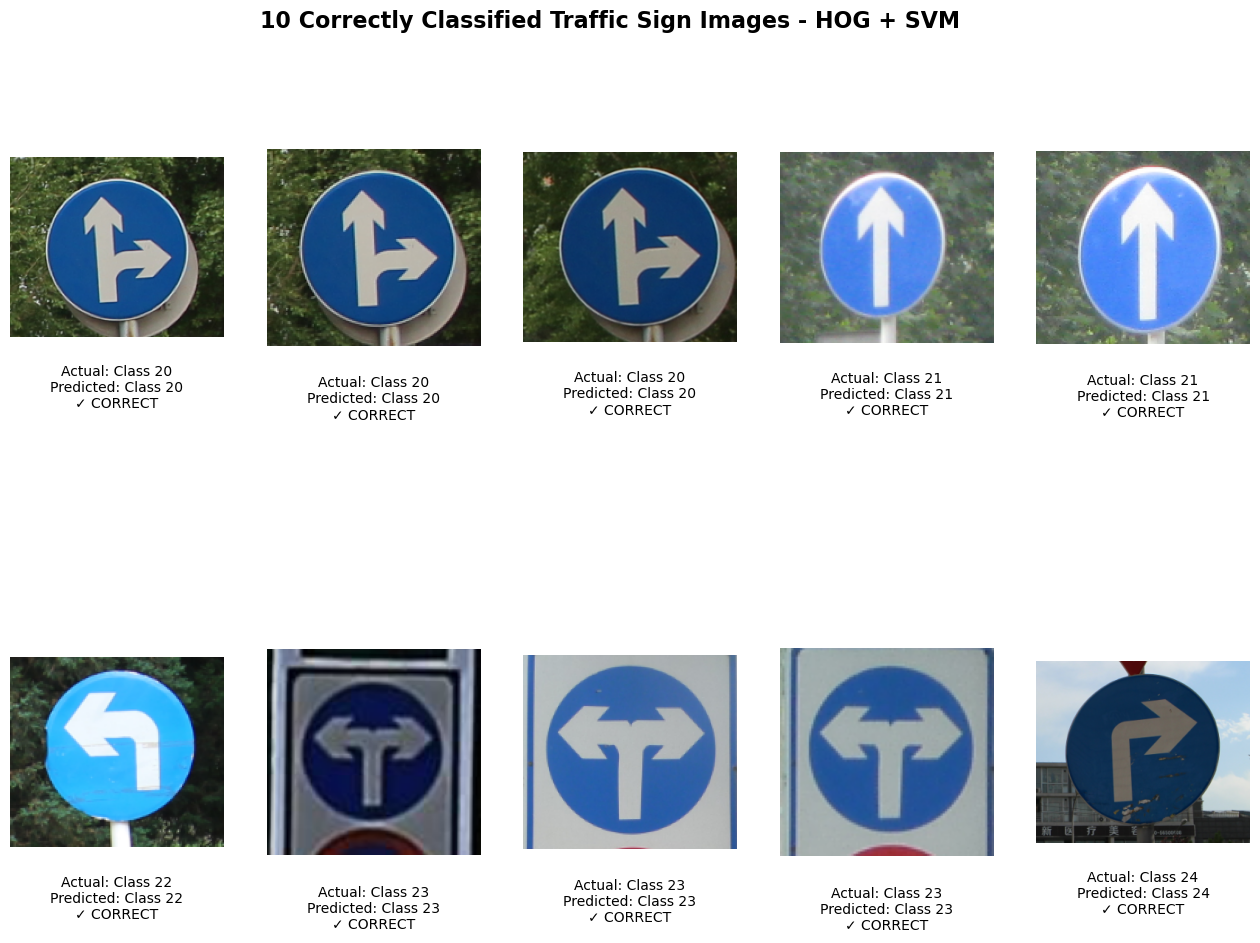

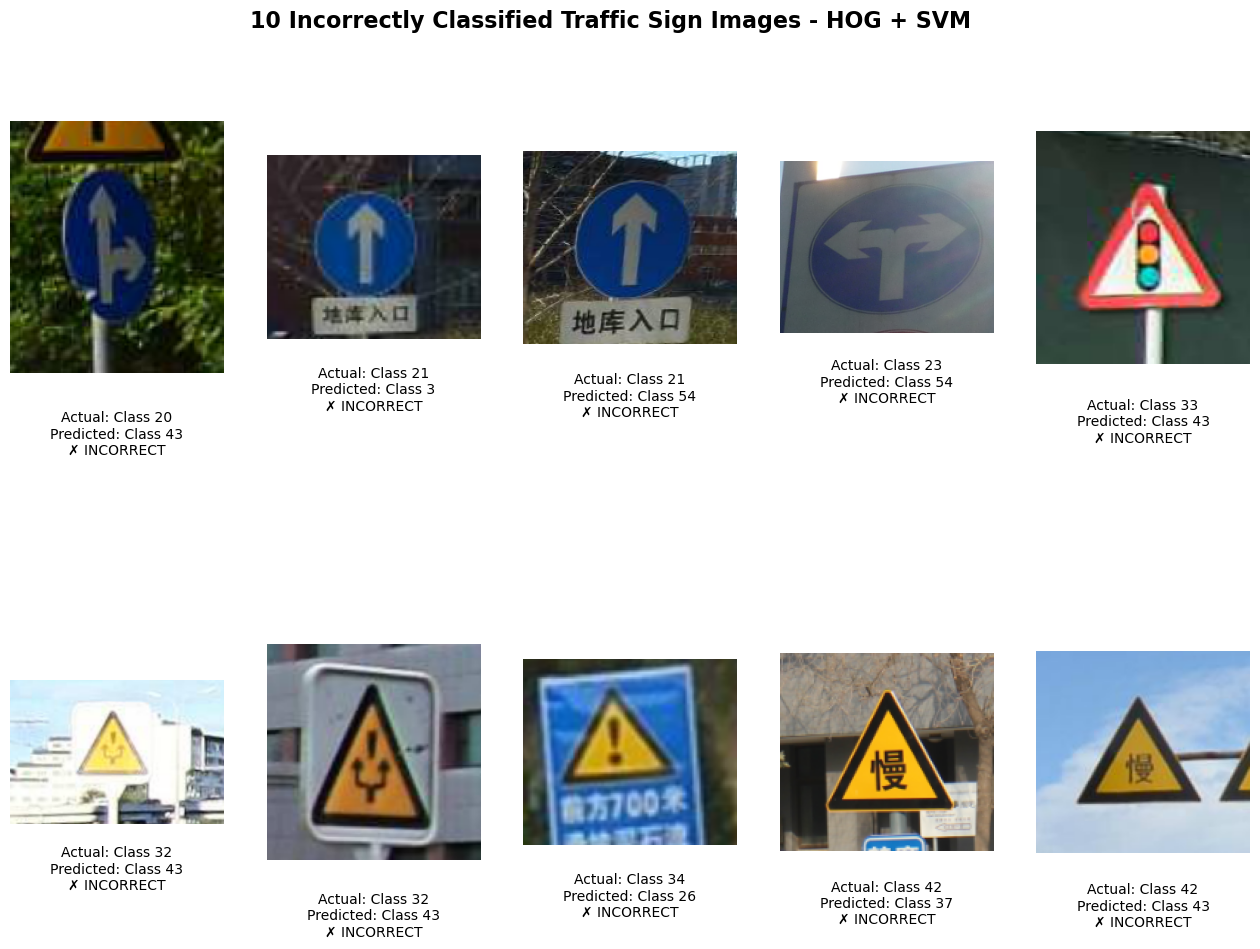

In [5]:
# ============================================================
# CELL 3: VISUALIZE 10 CORRECT AND 10 INCORRECT PREDICTIONS
# ============================================================

import cv2
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. FIND ALL TEST IMAGES
# ------------------------------------------------------------

image_files = sorted([
    p for p in TEST_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
])

print(f"Test images found: {len(image_files)}")
print(f"Test labels: {len(y_test)}")

if len(image_files) != len(y_test):
    raise ValueError(
        f"Number of test images ({len(image_files)}) "
        f"does not match number of test labels ({len(y_test)})."
    )


# ------------------------------------------------------------
# 2. FIND CORRECT AND INCORRECT PREDICTIONS
# ------------------------------------------------------------

correct_indices = np.where(y_test == y_test_pred)[0]
incorrect_indices = np.where(y_test != y_test_pred)[0]

print(f"\nCorrect predictions  : {len(correct_indices)}")
print(f"Incorrect predictions: {len(incorrect_indices)}")


# ------------------------------------------------------------
# 3. DISPLAY FUNCTION
# ------------------------------------------------------------

def display_predictions(indices, title):

    # Show maximum 10 images
    indices = indices[:10]

    fig, axes = plt.subplots(2, 5, figsize=(16, 10))
    axes = axes.ravel()

    for i, idx in enumerate(indices):

        # Read image
        image = cv2.imread(str(image_files[idx]))

        if image is None:
            axes[i].axis("off")
            continue

        # Convert BGR → RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Display image
        axes[i].imshow(image)

        # Get class IDs
        actual = int(y_test[idx])
        predicted = int(y_test_pred[idx])

        # Determine result
        if actual == predicted:
            result = "✓ CORRECT"
        else:
            result = "✗ INCORRECT"

        # Put information BELOW the image
        axes[i].text(
            0.5,
            -0.15,
            f"Actual: Class {actual}\n"
            f"Predicted: Class {predicted}\n"
            f"{result}",
            transform=axes[i].transAxes,
            ha="center",
            va="top",
            fontsize=10
        )

        axes[i].axis("off")

    # Hide unused spaces
    for i in range(len(indices), 10):
        axes[i].axis("off")

    # Main title
    plt.suptitle(
        title,
        fontsize=16,
        fontweight="bold",
        y=0.98
    )

    # Add more space between rows
    plt.subplots_adjust(
        top=0.90,
        bottom=0.08,
        hspace=0.6,
        wspace=0.2
    )

    plt.show()


# ------------------------------------------------------------
# 4. SHOW 10 CORRECT PREDICTIONS
# ------------------------------------------------------------

display_predictions(
    correct_indices,
    "10 Correctly Classified Traffic Sign Images - HOG + SVM"
)


# ------------------------------------------------------------
# 5. SHOW 10 INCORRECT PREDICTIONS
# ------------------------------------------------------------

display_predictions(
    incorrect_indices,
    "10 Incorrectly Classified Traffic Sign Images - HOG + SVM"
)